# Aula 4 - Explorando dados com seaborn

## Exploratory Data Analysis (EDA)

### Importando Bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

### Dataframe

| Coluna | Significado em Português |
|:---|:---|
| **age** | Idade (em anos) |
| **sex** | Sexo ($\text{1} = \text{masculino}$; $\text{0} = \text{feminino}$) |
| **cp** | Tipo de dor no peito (chest pain type) |
| **trtbps** | Pressão arterial em repouso (resting blood pressure, em $\text{mm Hg}$) |
| **chol** | Colesterol sérico (em $\text{mg/dl}$) |
| **fbs** | Açúcar no sangue em jejum (fasting blood sugar). ($\text{1}$ se $> \text{120 mg/dl}$; $\text{0}$ caso contrário) |
| **restecg** | Resultados eletrocardiográficos em repouso |
| **thalachh** | Frequência cardíaca máxima atingida (maximum heart rate achieved) |
| **exng** | Angina induzida por exercício ($\text{1} = \text{sim}$; $\text{0} = \text{não}$) |
| **oldpeak** | Depressão do segmento $\text{ST}$ induzida por exercício em relação ao repouso |
| **slp** | Inclinação do segmento $\text{ST}$ de pico de exercício (slope of the peak exercise $\text{ST}$ segment) |
| **caa** | Número de vasos principais ($\text{0}-\text{3}$) coloridos por fluoroscopia |
| **thall** | Tipo de talassemia |
| **output** | Variável alvo (**Target**): Indica a presença de doença cardíaca ($\text{1} = \text{sim}$; $\text{0} = \text{não}$) |

In [2]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
df_heart = pd.read_csv("/content/drive/MyDrive/Python para Visualização/Dados/heart.csv")

In [4]:
df_heart.head()

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


**Informações do DatraFrame**

In [5]:
df_heart.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trtbps    303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalachh  303 non-null    int64  
 8   exng      303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slp       303 non-null    int64  
 11  caa       303 non-null    int64  
 12  thall     303 non-null    int64  
 13  output    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


**Describe do DataFrame**

In [6]:
df_heart.describe()

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [7]:
df_heart.columns

Index(['age', 'sex', 'cp', 'trtbps', 'chol', 'fbs', 'restecg', 'thalachh',
       'exng', 'oldpeak', 'slp', 'caa', 'thall', 'output'],
      dtype='object')

**Separação de Variáveis**

In [8]:
X = df_heart.drop(columns='output')
y = df_heart['output']

In [9]:
X

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3


Gerar um modelo de Machine Learning (classificação):
- Tem a doença ou não --> output (y)
- Quais características o modelo vai usar para essa classificação? --> features (X)

In [10]:
y

,output
0,1
1,1
2,1
3,1
4,1
...,...
298,0
299,0
300,0
301,0


**Missing values**

In [11]:
df_heart.isnull().sum()

,0
age,0
sex,0
cp,0
trtbps,0
chol,0
fbs,0
restecg,0
thalachh,0
exng,0
oldpeak,0


### Análise Univariada
Variável target

**Pergunta:** Existe diferença entre a proporção de pessoas com doenças cardíacas e saudáveis na base?

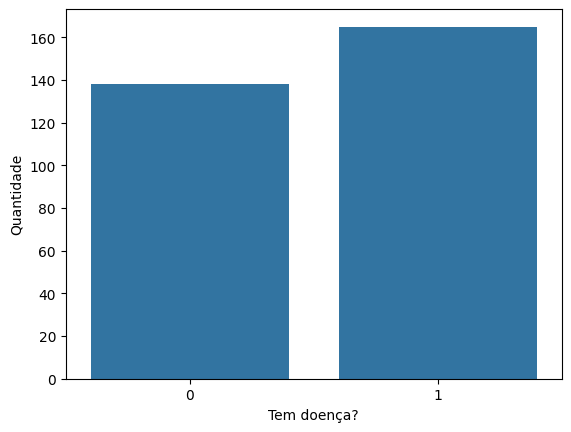

In [17]:
sns.countplot(data=df_heart, x = 'output')
plt.ylabel('Quantidade')
plt.xlabel('Tem doença?')
plt.show()

Varáveis Contínuas

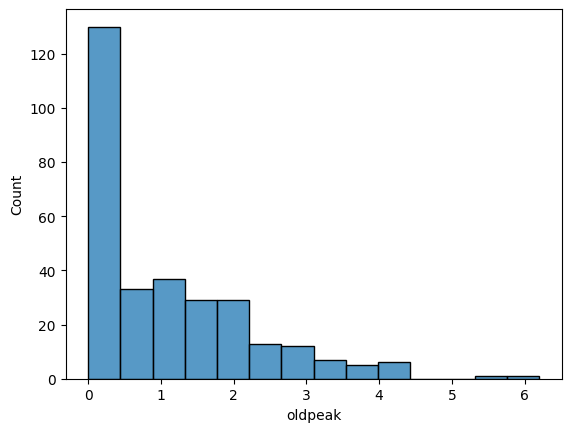

In [16]:
sns.histplot(data=df_heart, x = 'oldpeak')
plt.show()

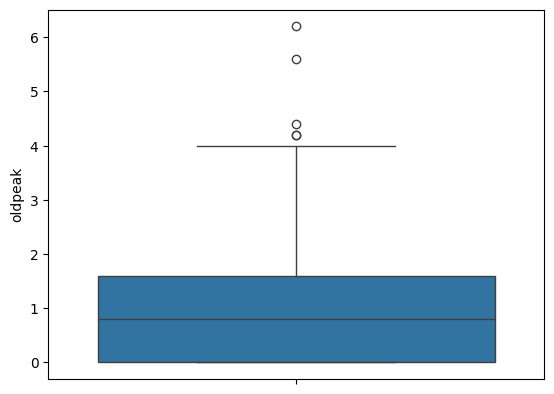

In [19]:
sns.boxplot(data=df_heart, y='oldpeak')
plt.show()

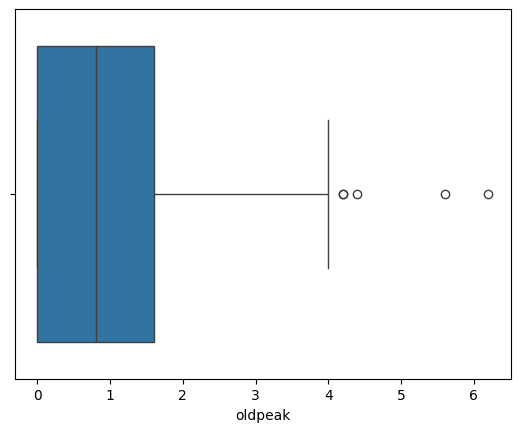

In [20]:
sns.boxplot(data=df_heart, x='oldpeak')
plt.show()

In [29]:
target = 'output'
vars_categ = ['sex', 'exng', 'cp', 'caa', 'fbs', 'restecg', 'slp', 'thall']
vars_cont = ['age', 'trtbps', 'chol', 'thalachh', 'oldpeak']

In [23]:
len(vars_cont)

5

In [25]:
vars_cont[0]

'age'

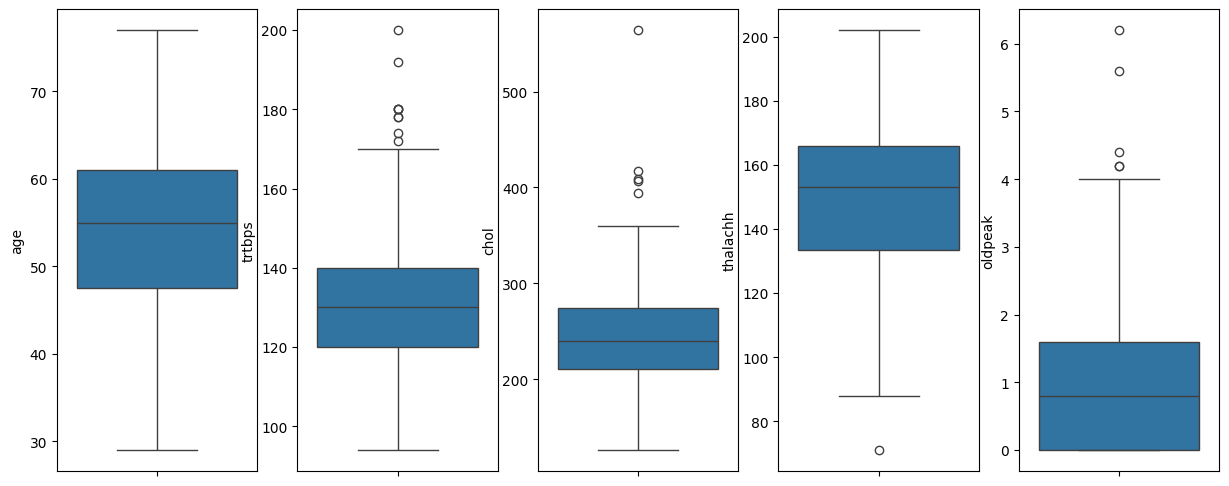

In [28]:
fig, ax = plt.subplots(1, len(vars_cont), figsize = (15,6))

for i in range(len(vars_cont)):
  sns.boxplot(data=df_heart, y=vars_cont[i], ax = ax[i])
plt.show()

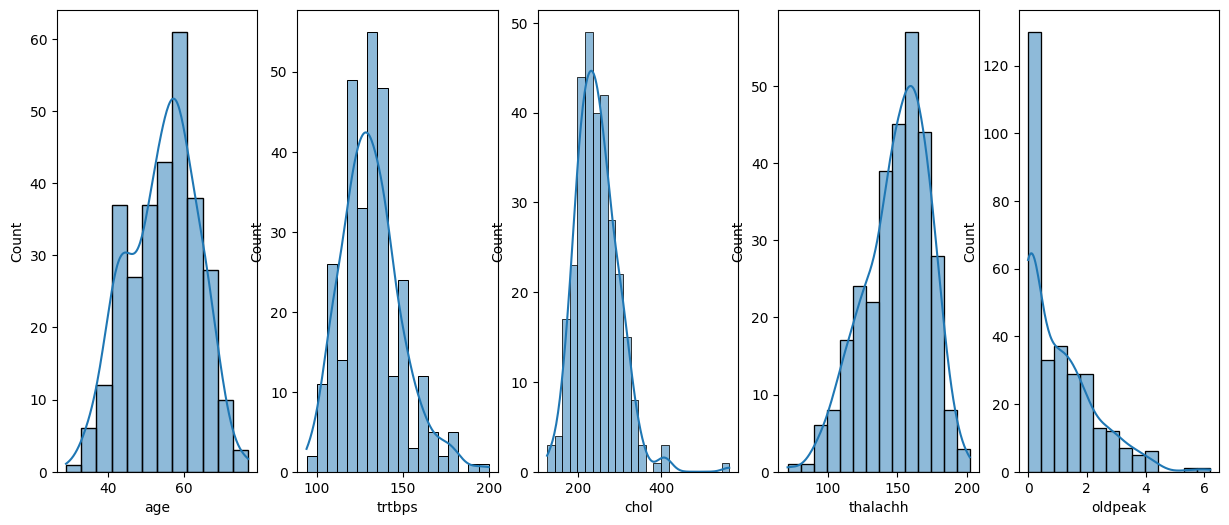

In [32]:
fig, ax = plt.subplots(1, len(vars_cont), figsize = (15,6))

for i in range(len(vars_cont)):
  sns.histplot(data=df_heart, x=vars_cont[i], ax = ax[i], kde=True)
plt.show()

Variáveis categóricas

In [34]:
len(vars_categ)

8

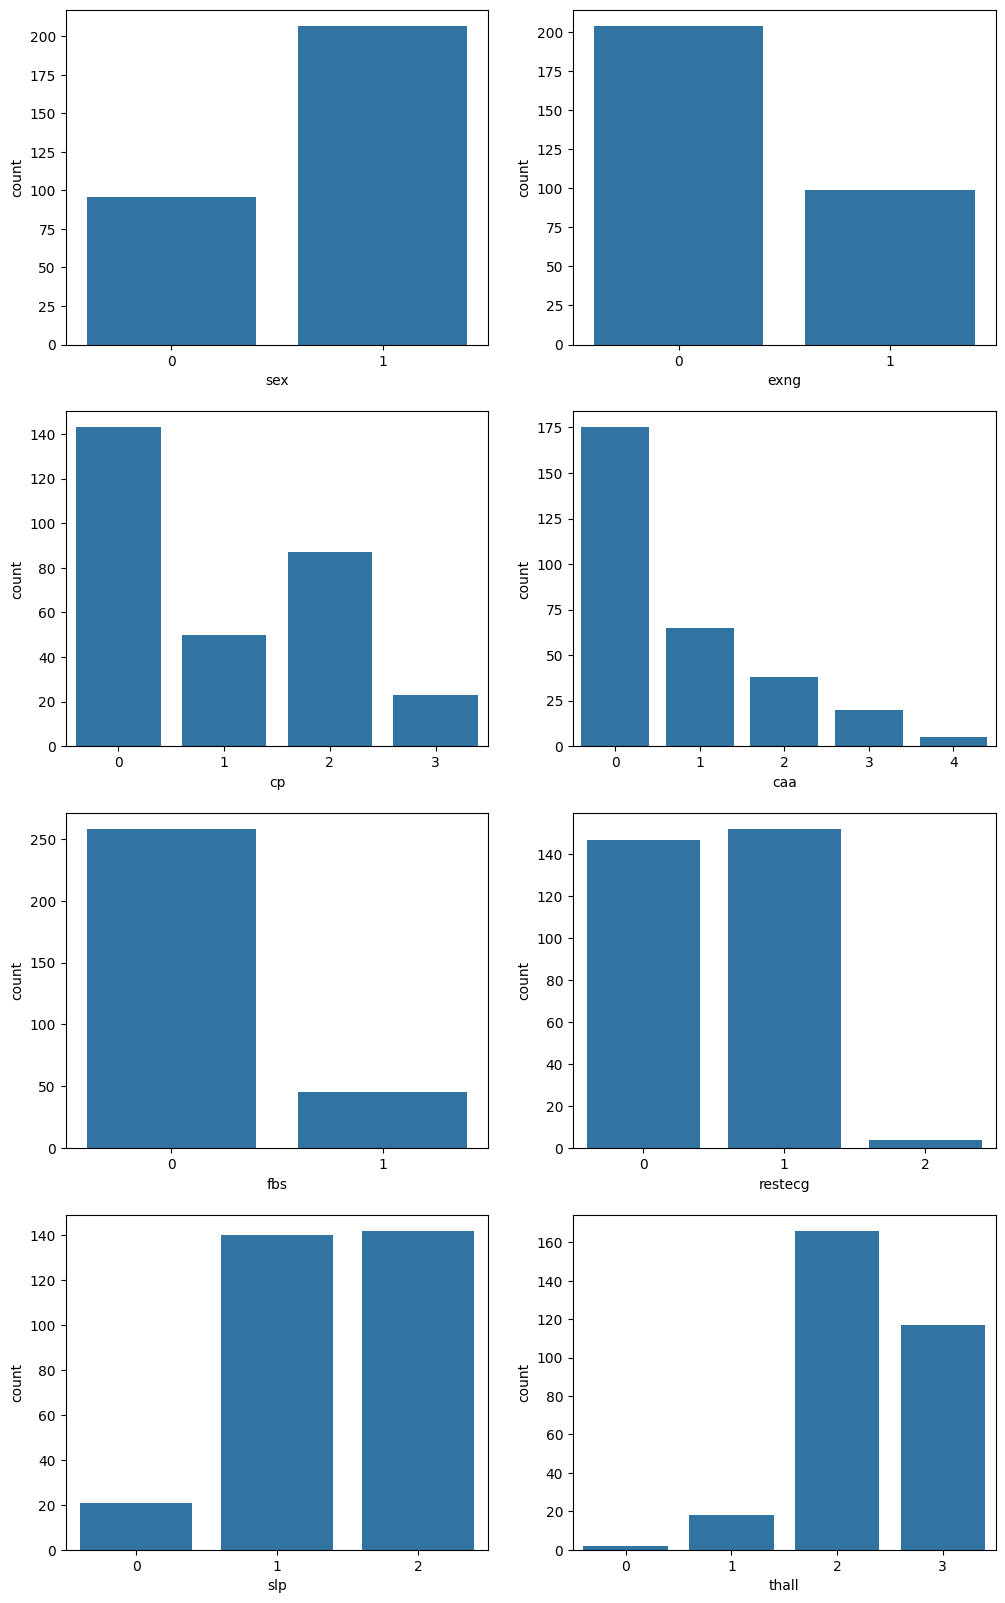

In [41]:
fig, ax = plt.subplots(4, 2, figsize = (12,20))
cont = 0
for i in range(4):
  for j in range(2):
    sns.countplot(data=df_heart, x=vars_categ[cont], ax = ax[i][j])
    cont += 1
plt.show()

### Análise Multivariada

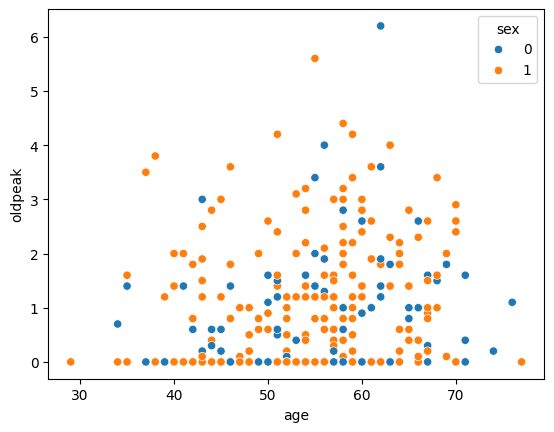

In [44]:
sns.scatterplot(data=df_heart, x = 'age', y = 'oldpeak', hue='sex')
plt.show()

In [45]:
df_heart.corr()

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
age,1.000000,-0.098447,-0.068653,0.279351,0.213678,0.121308,-0.116211,-0.398522,0.096801,0.210013,-0.168814,0.276326,0.068001,-0.225439
sex,-0.098447,1.000000,-0.049353,-0.056769,-0.197912,0.045032,-0.058196,-0.044020,0.141664,0.096093,-0.030711,0.118261,0.210041,-0.280937
cp,-0.068653,-0.049353,1.000000,0.047608,-0.076904,0.094444,0.044421,0.295762,-0.394280,-0.149230,0.119717,-0.181053,-0.161736,0.433798
trtbps,0.279351,-0.056769,0.047608,1.000000,0.123174,0.177531,-0.114103,-0.046698,0.067616,0.193216,-0.121475,0.101389,0.062210,-0.144931
chol,0.213678,-0.197912,-0.076904,0.123174,1.000000,0.013294,-0.151040,-0.009940,0.067023,0.053952,-0.004038,0.070511,0.098803,-0.085239
fbs,0.121308,0.045032,0.094444,0.177531,0.013294,1.000000,-0.084189,-0.008567,0.025665,0.005747,-0.059894,0.137979,-0.032019,-0.028046
restecg,-0.116211,-0.058196,0.044421,-0.114103,-0.151040,-0.084189,1.000000,0.044123,-0.070733,-0.058770,0.093045,-0.072042,-0.011981,0.137230
thalachh,-0.398522,-0.044020,0.295762,-0.046698,-0.009940,-0.008567,0.044123,1.000000,-0.378812,-0.344187,0.386784,-0.213177,-0.096439,0.421741
exng,0.096801,0.141664,-0.394280,0.067616,0.067023,0.025665,-0.070733,-0.378812,1.000000,0.288223,-0.257748,0.115739,0.206754,-0.436757
oldpeak,0.210013,0.096093,-0.149230,0.193216,0.053952,0.005747,-0.058770,-0.344187,0.288223,1.000000,-0.577537,0.222682,0.210244,-0.430696


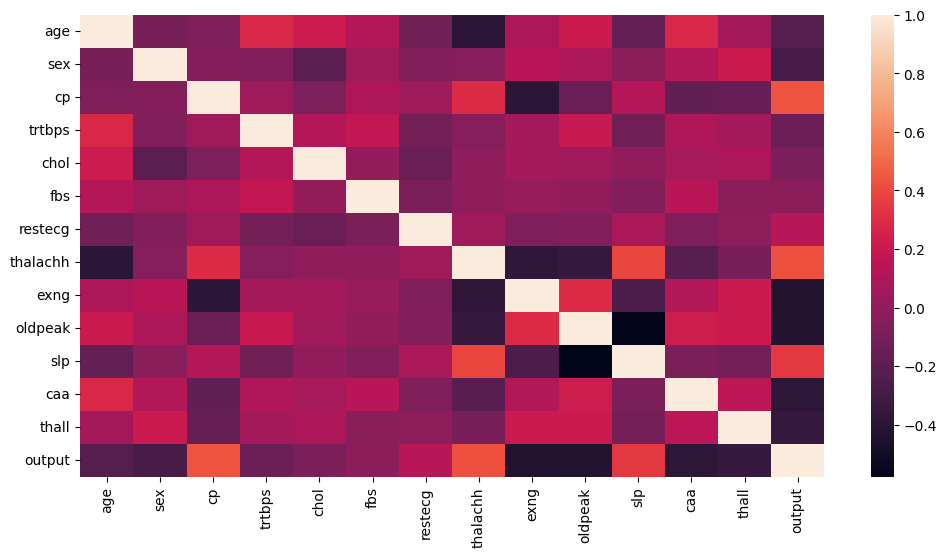

In [46]:
#Heatmap
plt.figure(figsize=(12,6))
sns.heatmap(df_heart.corr())
plt.show()

<Figure size 3000x3000 with 0 Axes>

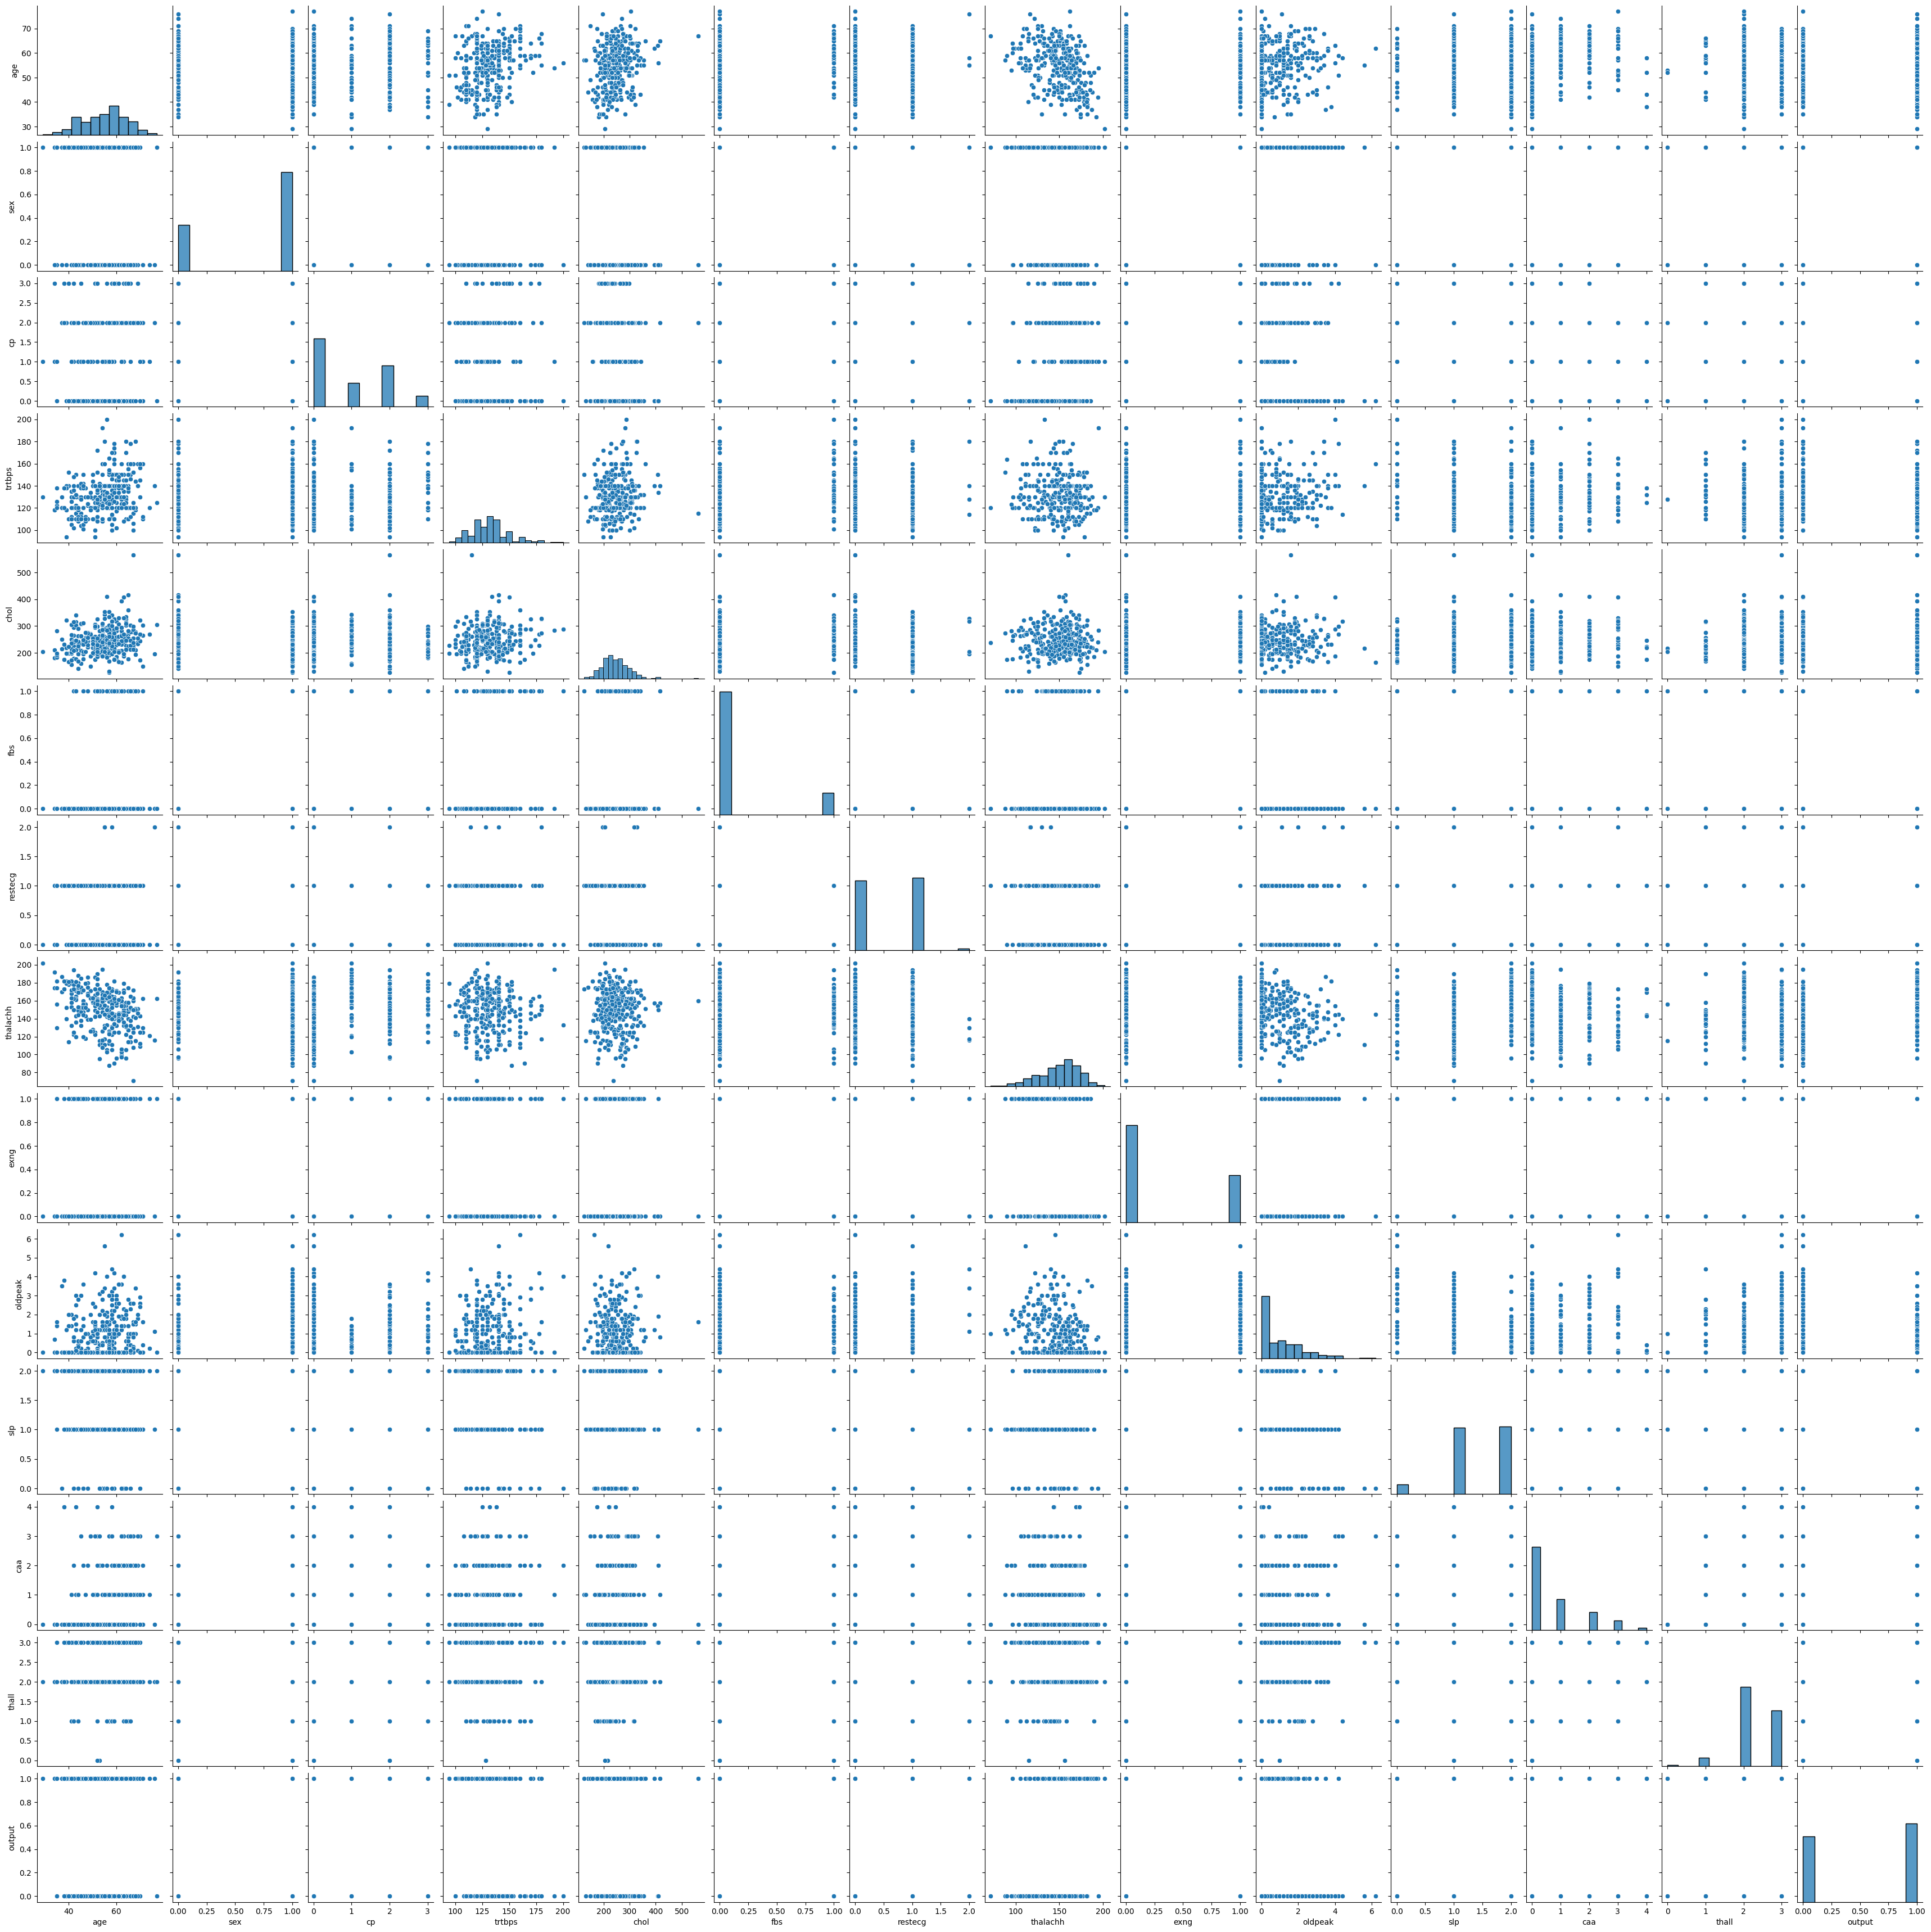

In [48]:
#Pairplot
plt.figure(figsize=(30,30))
sns.pairplot(df_heart)
plt.show()

<Figure size 1500x1500 with 0 Axes>

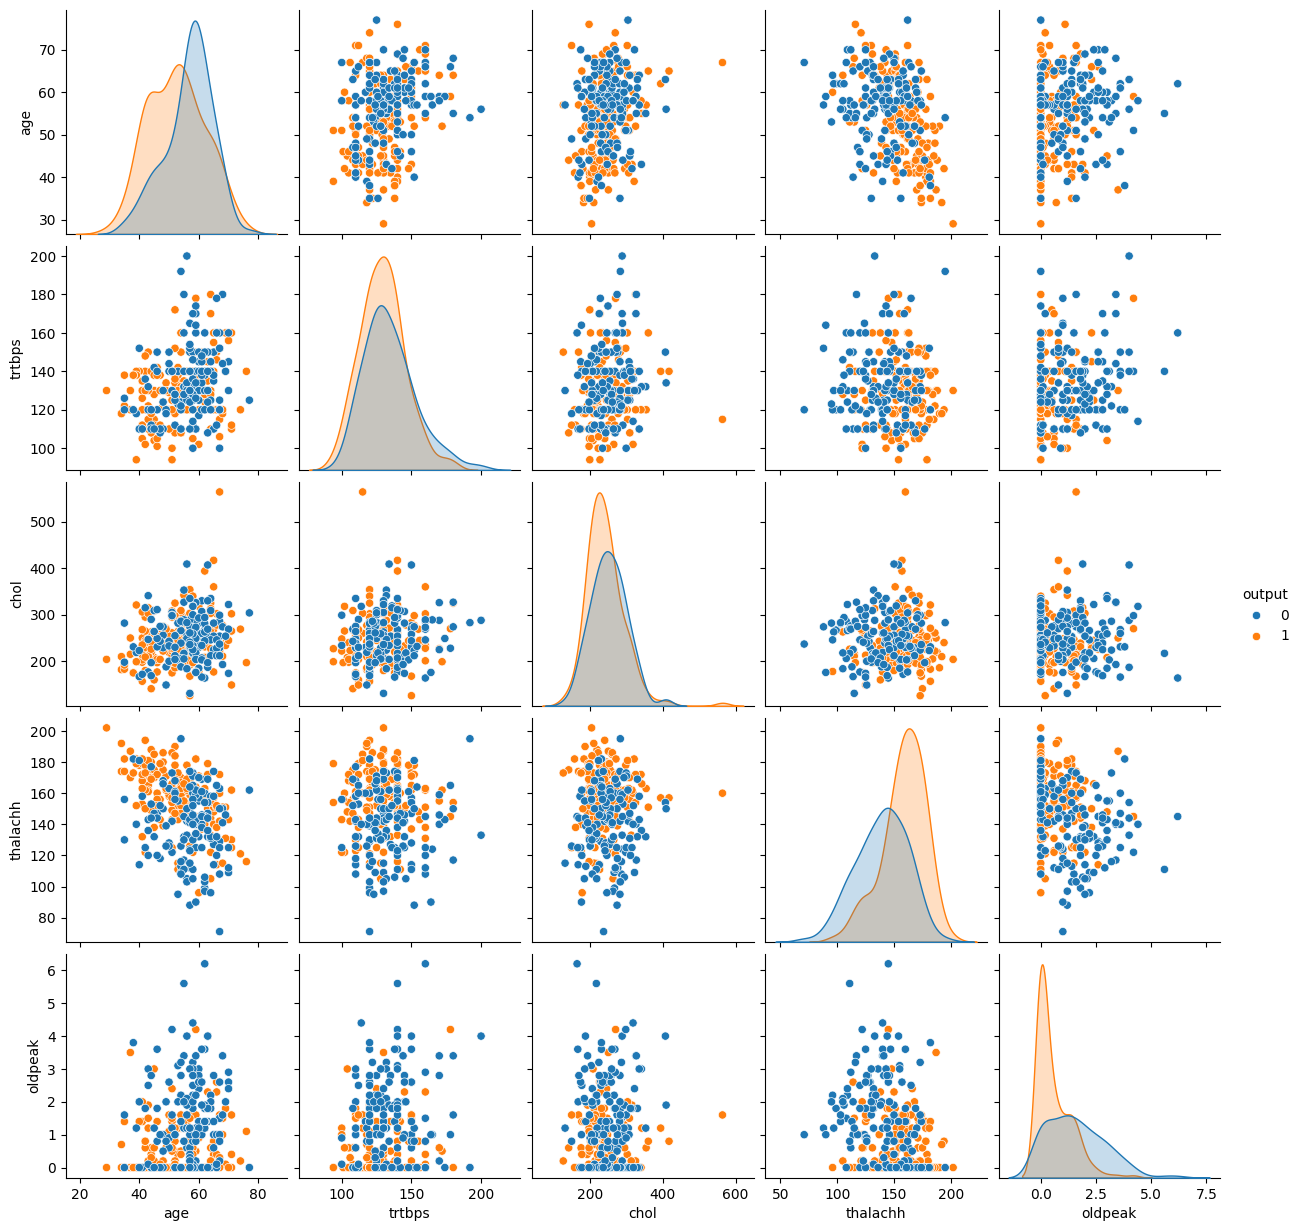

In [51]:
#Pairplot
plt.figure(figsize=(15,15))
sns.pairplot(df_heart[['age', 'trtbps', 'chol', 'thalachh', 'oldpeak','output']], hue='output')
plt.show()

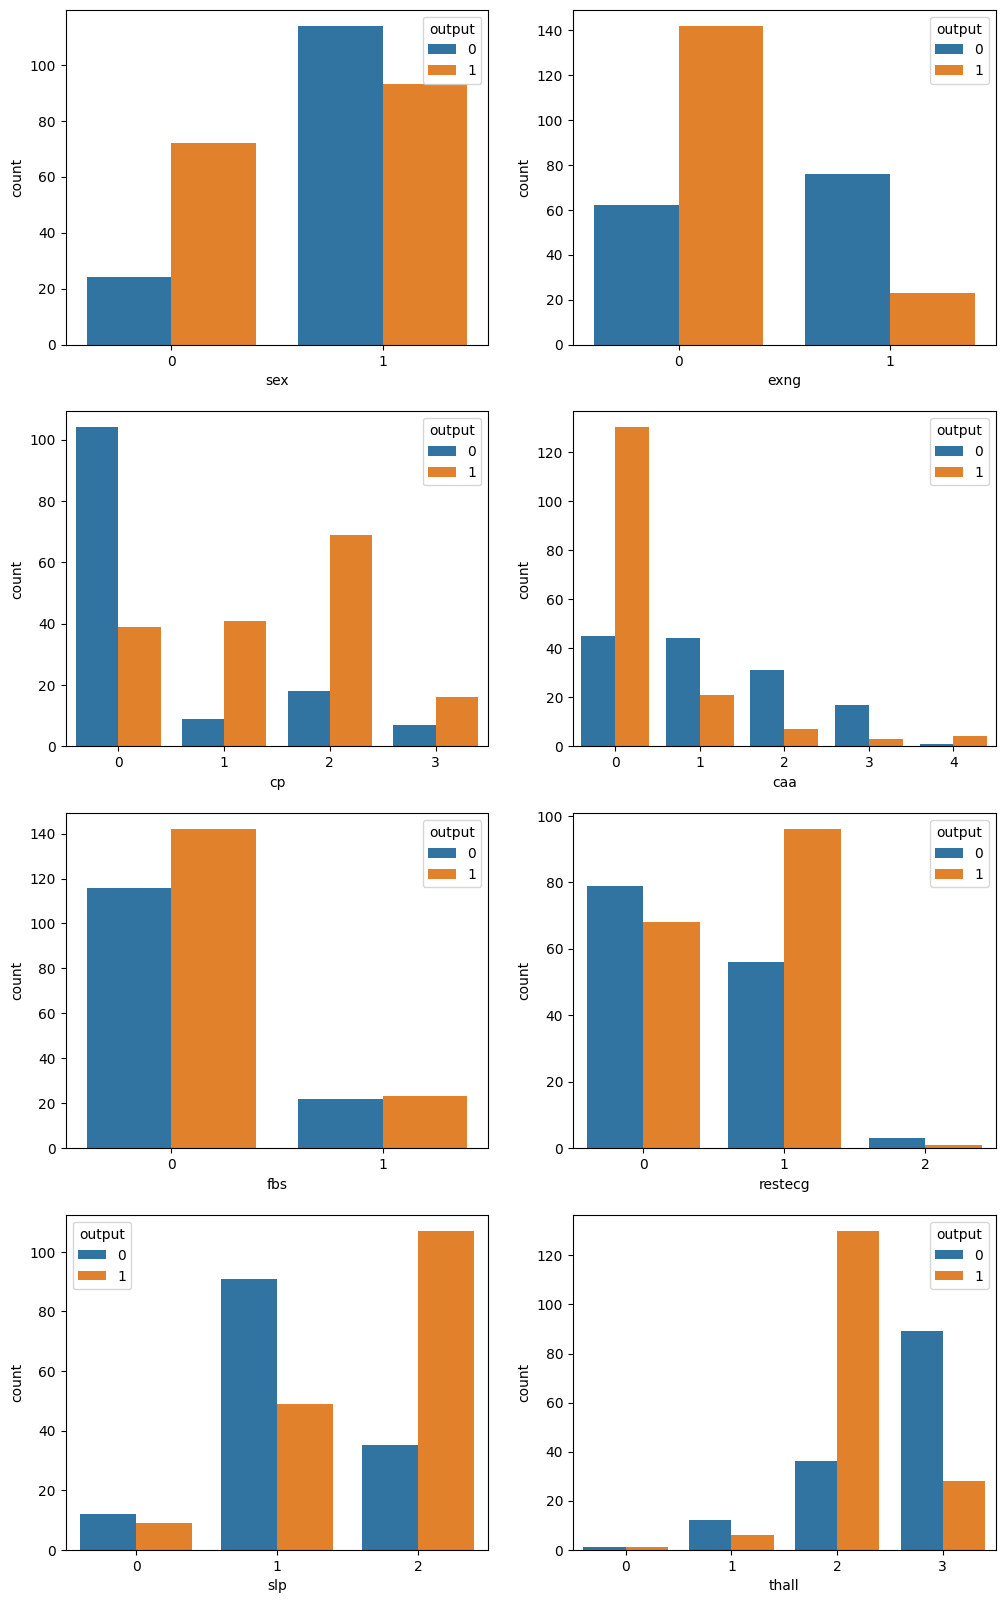

In [52]:
fig, ax = plt.subplots(4, 2, figsize = (12,20))
cont = 0
for i in range(4):
  for j in range(2):
    sns.countplot(data=df_heart, x=vars_categ[cont], ax = ax[i][j], hue='output')
    cont += 1
plt.show()

<Figure size 1500x1500 with 0 Axes>

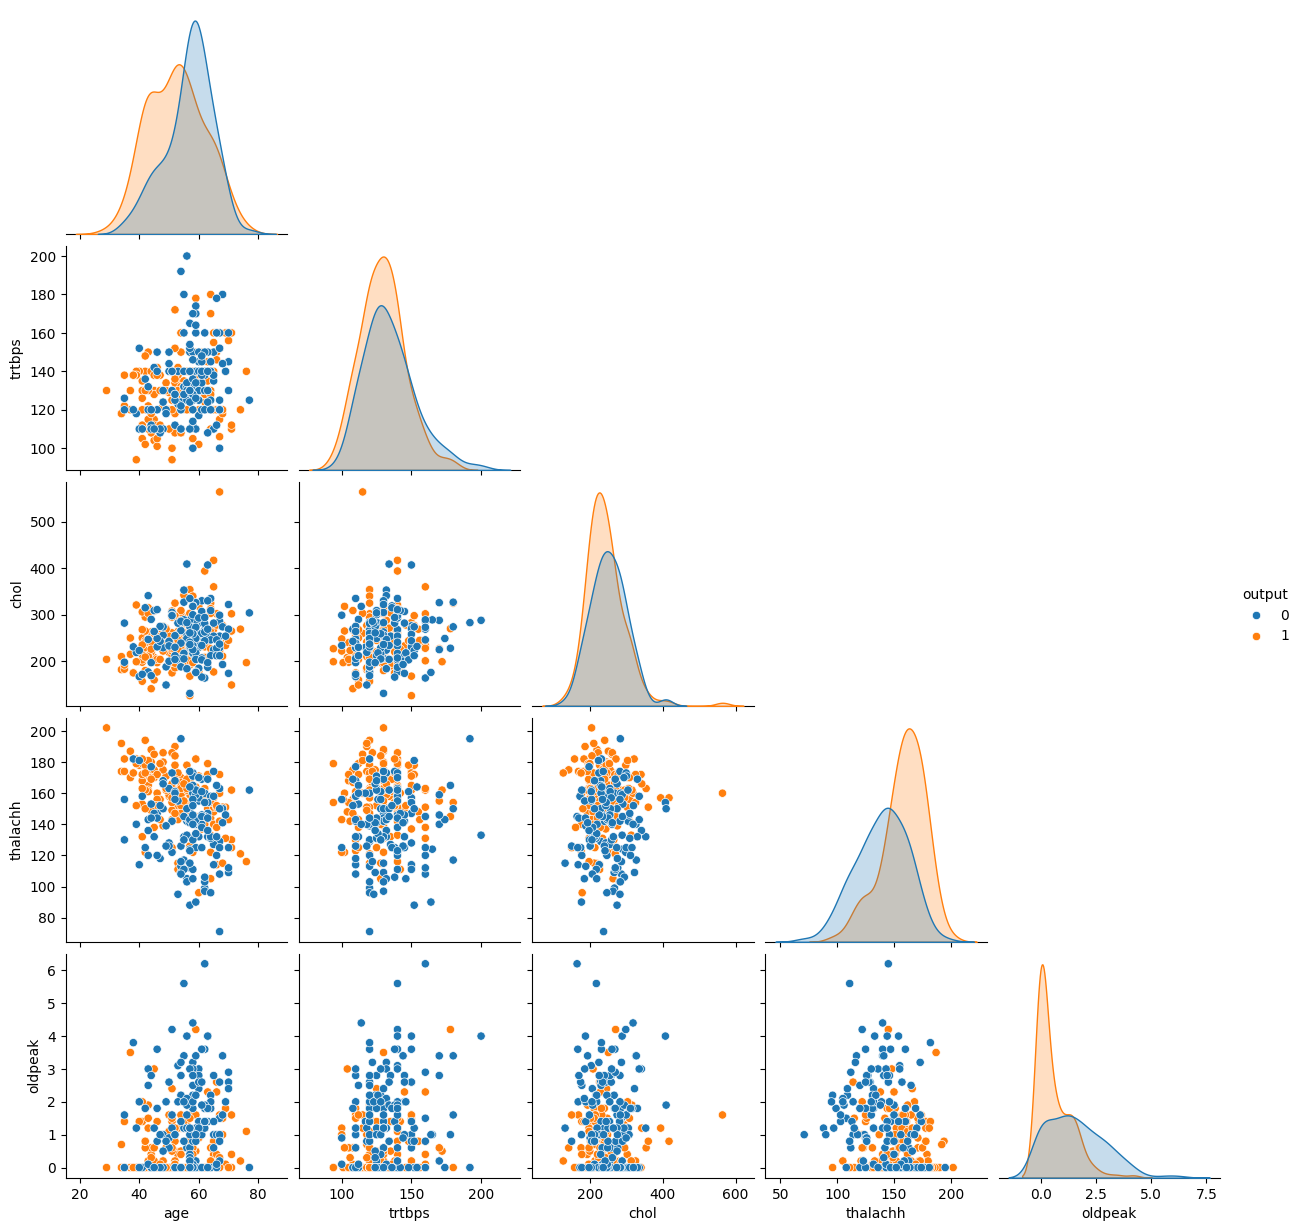

In [53]:
#Pairplot
plt.figure(figsize=(15,15))
sns.pairplot(df_heart[['age', 'trtbps', 'chol', 'thalachh', 'oldpeak','output']], hue='output', corner=True)
plt.show()

In [56]:
df_heart.columns

Index(['age', 'sex', 'cp', 'trtbps', 'chol', 'fbs', 'restecg', 'thalachh',
       'exng', 'oldpeak', 'slp', 'caa', 'thall', 'output'],
      dtype='object')

In [59]:
df_heart['caa']

,caa
0,0
1,0
2,0
3,0
4,0
...,...
298,0
299,0
300,2
301,1


<Axes: xlabel='caa', ylabel='chol'>

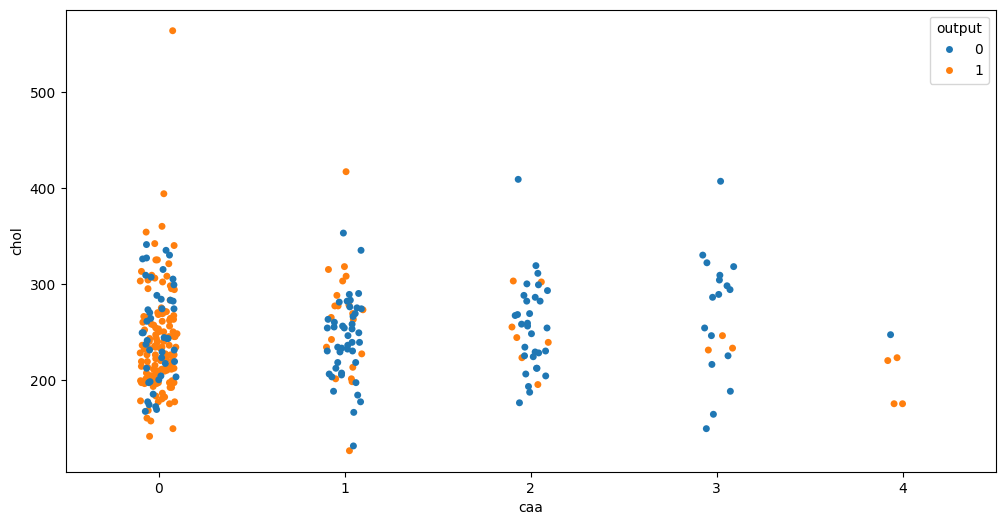

In [60]:
plt.figure(figsize=(12,6))
sns.stripplot(data=df_heart, x = 'caa', y = 'chol', hue='output')

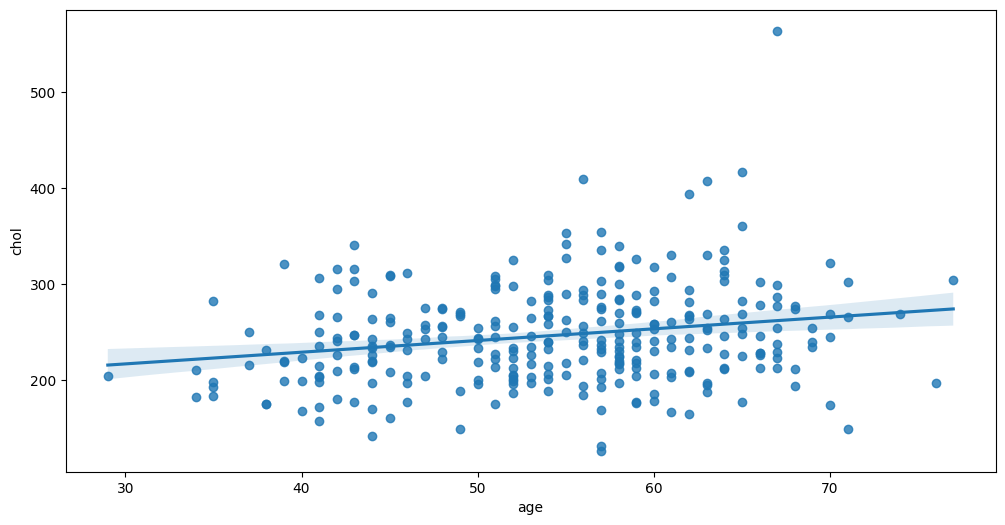

In [65]:
plt.figure(figsize=(12,6))
sns.regplot(data=df_heart, x = 'age', y = 'chol', order=1)
plt.show()

In [69]:
vars_cont

['age', 'trtbps', 'chol', 'thalachh', 'oldpeak']

<Axes: xlabel='sex', ylabel='age'>

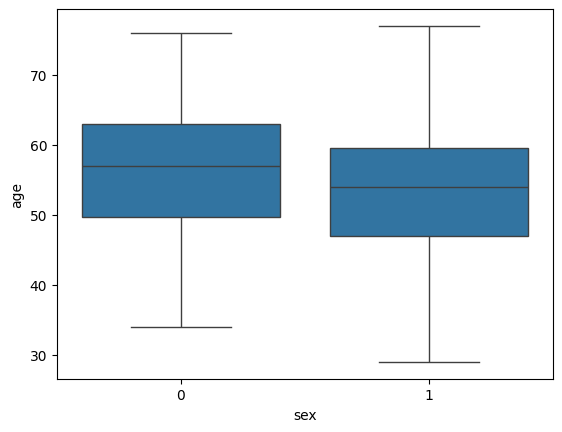

In [71]:
sns.boxplot(data=df_heart, y='age', x = 'sex')

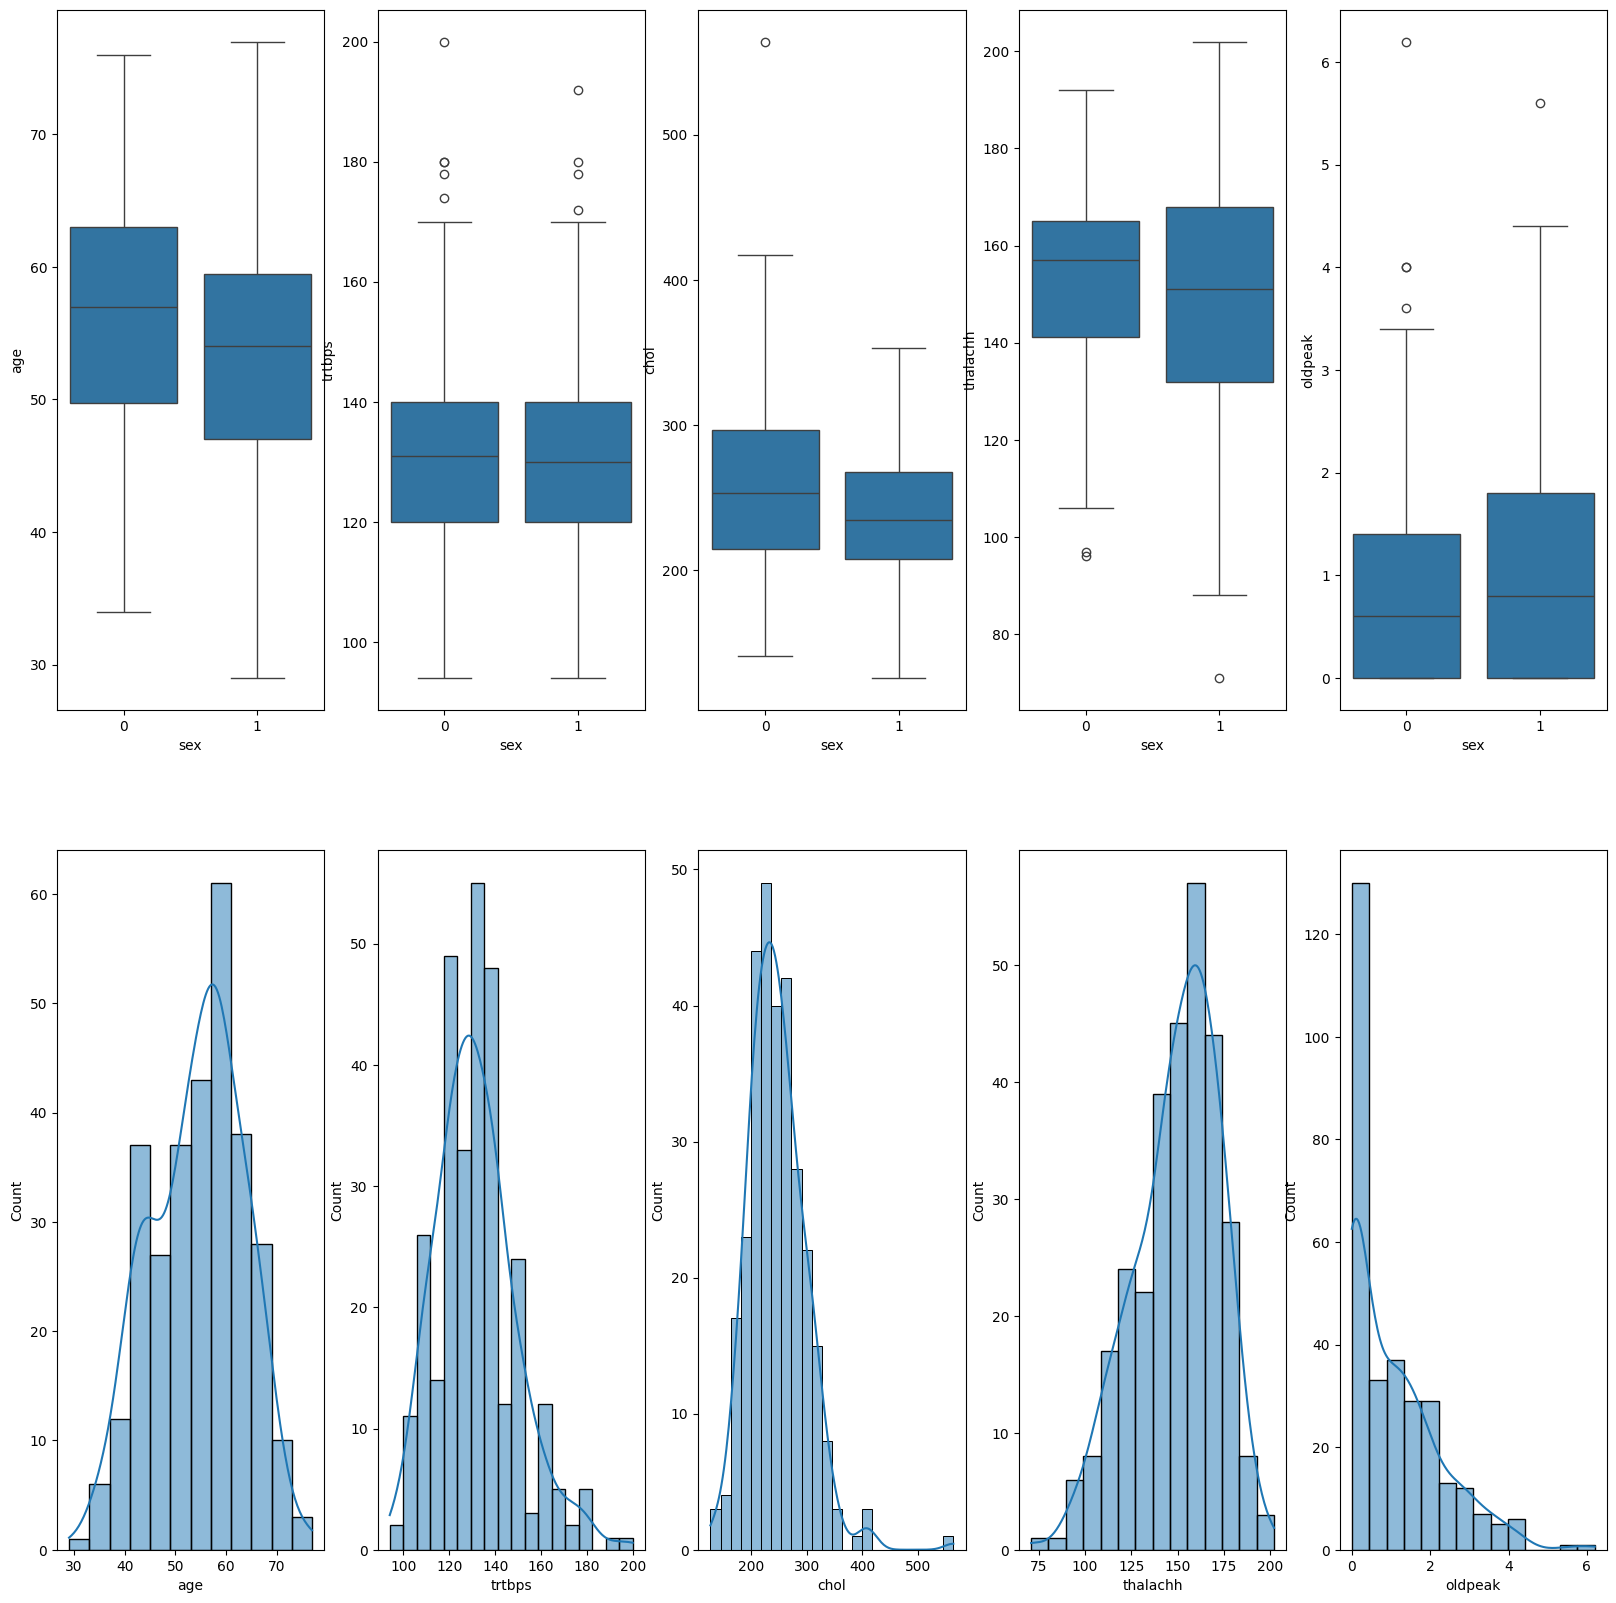

In [75]:
fig, (axes_box, axes_hist) = plt.subplots(2, len(vars_cont), figsize = (20,20))

cont = 0
for i,name in enumerate(vars_cont):
  i, j = divmod(cont, 5)
  sns.boxplot(data=df_heart, y=name, x = 'sex', ax = axes_box[j])
  sns.histplot(data=df_heart, x=name, ax = axes_hist[j], kde=True)
  cont+=1
plt.show()